# NAB Anomaly Detection — Final Comparison: Isolation Forest vs LSTM Autoencoder

**Goal:** Summarize and compare both detectors on the official NAB score across the 17 
`realAWSCloudwatch` files, and draw conclusions for the project report.

In [2]:
import pandas as pd

summary = pd.DataFrame({
    "Profile": ["Standard", "Reward low FP", "Reward low FN"],
    "Isolation Forest": [80.35, 76.29, 85.65],
    "LSTM Autoencoder": [72.34, 72.04, 77.72],
})
summary["Difference (IF - LSTM)"] = summary["Isolation Forest"] - summary["LSTM Autoencoder"]

summary

,Profile,Isolation Forest,LSTM Autoencoder,Difference (IF - LSTM)
0,Standard,80.35,72.34,8.01
1,Reward low FP,76.29,72.04,4.25
2,Reward low FN,85.65,77.72,7.93


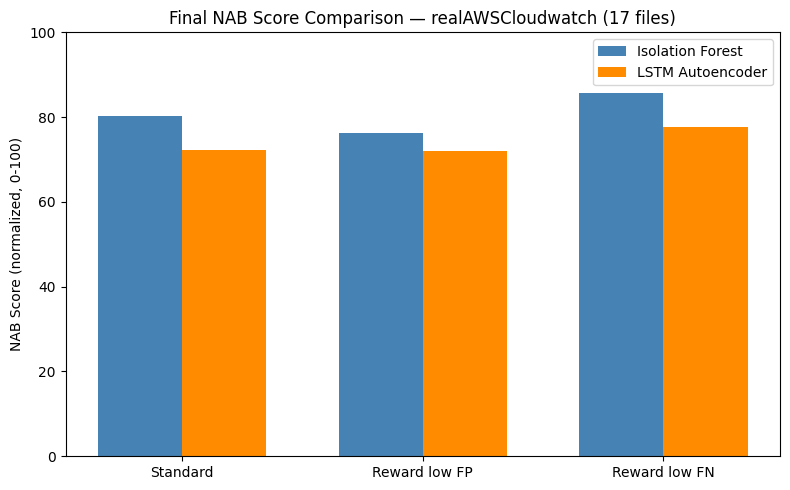

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
width = 0.35

ax.bar(x - width/2, summary["Isolation Forest"], width, label="Isolation Forest", color="steelblue")
ax.bar(x + width/2, summary["LSTM Autoencoder"], width, label="LSTM Autoencoder", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(summary["Profile"])
ax.set_ylabel("NAB Score (normalized, 0-100)")
ax.set_title("Final NAB Score Comparison — realAWSCloudwatch (17 files)")
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Conclusion

On this evaluation (17 files from the `realAWSCloudwatch` NAB category), **Isolation Forest 
outperforms the LSTM Autoencoder** on all three NAB scoring profiles, contrary to the initial 
hypothesis that a temporal deep learning model would better capture contextual anomalies.

**Key factors behind this result:**

- **Training data volume**: Isolation Forest is trained on the full available series (minus 
  the labeled anomaly window in the exploratory notebook, or with a small contamination 
  assumption in the official detector). The LSTM Autoencoder, to remain faithful to the NAB 
  protocol, is trained only on the probationary period (~15% of each file) — a significant 
  handicap for a data-hungry deep learning model.
- **Robustness across diverse signal types**: the `realAWSCloudwatch` files exhibit very 
  different normal behaviors (stable high-CPU, near-zero sparse spikes, noisy stable signals, 
  bursty duty-cycle patterns — see EDA notebook). Isolation Forest, using hand-engineered 
  features (rolling std, diff), generalizes more consistently across this diversity than a 
  fixed LSTM architecture trained per-file with limited data.
- **Qualitative inspection** (see per-file diagnosis on `grok_asg_anomaly.csv` and 
  `ec2_disk_write_bytes_c0d644.csv`) revealed that the LSTM Autoencoder does detect genuine, 
  strong signal changes — but these often don't align with the officially labeled windows, 
  suggesting either label imperfections or a notion of "normal" learned too narrowly from 
  limited training data.

**This result nuances rather than invalidates the deep learning hypothesis**: on the single 
file where it was trained with more representative data (exploratory notebook, `825cc2`), the 
LSTM Autoencoder's point-level F1 (0.501) exceeded Isolation Forest's (0.274). This suggests 
the approach has genuine potential, but requires either more training data per file, transfer 
learning across files, or a longer probationary period than the NAB protocol allows by default 
in this setup.